: 

# Reweighted 2D-1D wavelet deconvolution of a real ALMA dirty cube (TW Hya), vs. CASA multiscale CLEAN

The real-data counterpart of `songs_real_beam_demo.ipynb`. Same pipeline --
reweighted-soft 2D-1D wavelet deconvolution (`Deconvolver2D1D`), restored
with the clean beam, then flux/RMSE/background comparisons -- but run on a
genuine ALMA dirty cube and per-channel dirty beam instead of a simulated
cube with a real beam bolted on.

**Dataset**: TW Hya, CO(3-2) at 345.796 GHz, 40 channels around the line,
imaged from the calibrated measurement set with CASA `tclean`
(`weighting='briggs', robust=0.5, imsize=[256,256], cell='0.08arcsec'`). Two
`tclean` runs produced the FITS this notebook loads (see
`data/twhya/prep_wavelet_data.py`):

- `niter=0` -> the raw dirty cube (`twhya_dirty_cube.fits`) + per-channel
  dirty beam (`twhya_psf_cube.fits`).
- `deconvolver='multiscale', scales=[0,5,15], niter=5000, threshold='15mJy'`
  -> a professionally-cleaned benchmark (`twhya_clean_benchmark.fits`), with
  its per-channel restoring ("clean") beam stored in the FITS `BEAMS` table.

**No ground truth exists for real data** -- unlike the SONGS notebook, the
comparisons here are against CASA's multiscale-CLEAN benchmark (the
reference professional result) and each method's own noise behavior, not an
RMSE to a known answer. To put our wavelet model on the same footing as the
CASA benchmark (same resolution, same Jy/beam units), we convolve it with
**CASA's own clean beam** read from that `BEAMS` table.

Requires `astropy` (`pip install astropy`), used only for FITS I/O.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('../src'))

import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits

from io_fits import load_twhya_data, taper_psf, crop_psf_support
from deconvolver import Deconvolver2D1D, convolve_cube, lipschitz_constant

plt.rcParams['figure.facecolor'] = 'white'
DATA_DIR = '../data/twhya'

## 1. Load the real dirty cube, per-channel dirty beam, and CASA benchmark

Cropped to a centered 128x128 region (~10.2 arcsec at 0.08 arcsec/pixel),
comfortably larger than TW Hya's compact CO(3-2) disk and ~4x fewer pixels
than the full 256x256 CASA image.

In [2]:
d = load_twhya_data(DATA_DIR, crop=128, load_benchmark=True, load_residual=False)
dirty, psf, benchmark = d['dirty'], d['psf'], d['benchmark']
sigma_noise = d['sigma_noise']
nz, ny, nx = dirty.shape
cell_arcsec = d['cell_deg'] * 3600.0
peak_chan = int(np.argmax(dirty.max(axis=(1, 2))))

print(f'dirty cube shape = {dirty.shape}')
print(f'per-channel psf shape = {psf.shape} (varies slightly across the band)')
print(f'CASA multiscale-CLEAN benchmark shape = {benchmark.shape}')
print(f'pixel scale = {cell_arcsec:.3f} arcsec, rest freq = {d["restfreq_hz"]/1e9:.3f} GHz')
print(f'robust MAD noise estimate = {sigma_noise:.4g} Jy/beam')
print(f'brightest channel = {peak_chan} (dirty peak {dirty[peak_chan].max():.3f} Jy/beam)')

dirty cube shape = (40, 128, 128)
per-channel psf shape = (40, 128, 128) (varies slightly across the band)
CASA multiscale-CLEAN benchmark shape = (40, 128, 128)
pixel scale = 0.080 arcsec, rest freq = 372.650 GHz
robust MAD noise estimate = 0.04088 Jy/beam
brightest channel = 17 (dirty peak 0.904 Jy/beam)


In [9]:
print(psf_wavelet.shape, dirty.shape)

(40, 41, 41) (40, 128, 128)


## 2. CASA's clean beam (from the benchmark's `BEAMS` table)

CASA stores a per-channel restoring beam (elliptical Gaussian: BMAJ, BMIN in
arcsec, BPA in degrees). We take the median over channels as a single shared
clean beam -- the standard convention (real per-channel variation is tiny,
and CASA restores with one common beam by default). Convolving our wavelet
model with *this* beam is what makes it directly comparable to the CASA
benchmark image: same resolution, same Jy/beam units.

In [3]:
with fits.open(os.path.join(DATA_DIR, 'twhya_clean_benchmark.fits')) as h:
    beams = h['BEAMS'].data
bmaj_px = float(np.median(beams['BMAJ'])) / cell_arcsec
bmin_px = float(np.median(beams['BMIN'])) / cell_arcsec
bpa_deg = float(np.median(beams['BPA']))
print(f'CASA clean beam: BMAJ={np.median(beams["BMAJ"]):.3f}" BMIN={np.median(beams["BMIN"]):.3f}" '
      f'BPA={bpa_deg:.1f} deg')
print(f'               = {bmaj_px:.2f} x {bmin_px:.2f} pixels FWHM')

def elliptical_clean_beam(shape, fwhm_maj_px, fwhm_min_px, pa_deg, normalize='peak'):
    '''Rotated elliptical Gaussian clean beam. pa measured from +y (north)
    toward +x, CASA/FITS convention; major axis along y at pa=0.'''
    ny, nx = shape
    y = np.arange(ny) - ny // 2
    x = np.arange(nx) - nx // 2
    X, Y = np.meshgrid(x, y)
    pa = np.deg2rad(pa_deg)
    xr = X * np.cos(pa) + Y * np.sin(pa)
    yr = -X * np.sin(pa) + Y * np.cos(pa)
    s_maj = fwhm_maj_px / 2.3548200450309493
    s_min = fwhm_min_px / 2.3548200450309493
    g = np.exp(-(yr ** 2 / (2 * s_maj ** 2) + xr ** 2 / (2 * s_min ** 2)))
    return g / g.max() if normalize == 'peak' else g / g.sum()

# peak-normalized: convolving a sky model with it yields a Jy/beam image,
# matching the CASA benchmark's units so peak brightness compares directly.
clean_beam = elliptical_clean_beam((ny, nx), bmaj_px, bmin_px, bpa_deg, normalize='peak')
beam_area_px = clean_beam.sum()   # pixels per beam: Jy = (Jy/beam sum) / beam_area
print(f'clean-beam area = {beam_area_px:.2f} pixels/beam (for Jy/beam -> Jy flux conversion)')

CASA clean beam: BMAJ=0.635" BMIN=0.419" BPA=61.1 deg
               = 7.93 x 5.24 pixels FWHM
clean-beam area = 47.14 pixels/beam (for Jy/beam -> Jy flux conversion)


## 3. Conditioning the real dirty beam for the wavelet gradient step

A real ALMA dirty beam's sidelobes don't decay to ~0 within the field of
view, so FFT-convolving with the abruptly-truncated kernel inflates the
operator's Lipschitz constant and throttles the ISTA/FISTA step size
`mu = 1/L`. Cropping the beam to a 41-pixel support and tapering it
(`crop_psf_support` + `taper_psf`) fixes this for the wavelet path. (The
CASA benchmark and clean beam are untouched by this -- it only affects our
own gradient-based fit.)

In [4]:
L_untouched = lipschitz_constant(psf, (ny, nx))
psf_wavelet = taper_psf(crop_psf_support(psf, 41), flat_frac=0.0)
L_final = lipschitz_constant(psf_wavelet, (ny, nx))
print(f'Lipschitz constant, untouched 128-support psf : {L_untouched:10.1f}')
print(f'Lipschitz constant, tapered  41-support psf   : {L_final:10.1f}   <- used below')
print(f'step size mu=1/L: {1/L_untouched:.2e} -> {1/L_final:.2e}  ({L_untouched/L_final:.0f}x larger)')

Lipschitz constant, untouched 128-support psf :    26755.3
Lipschitz constant, tapered  41-support psf   :     1653.5   <- used below
step size mu=1/L: 3.74e-05 -> 6.05e-04  (16x larger)


## 4. Required figure: dirty beam, dirty channel, CASA benchmark channel

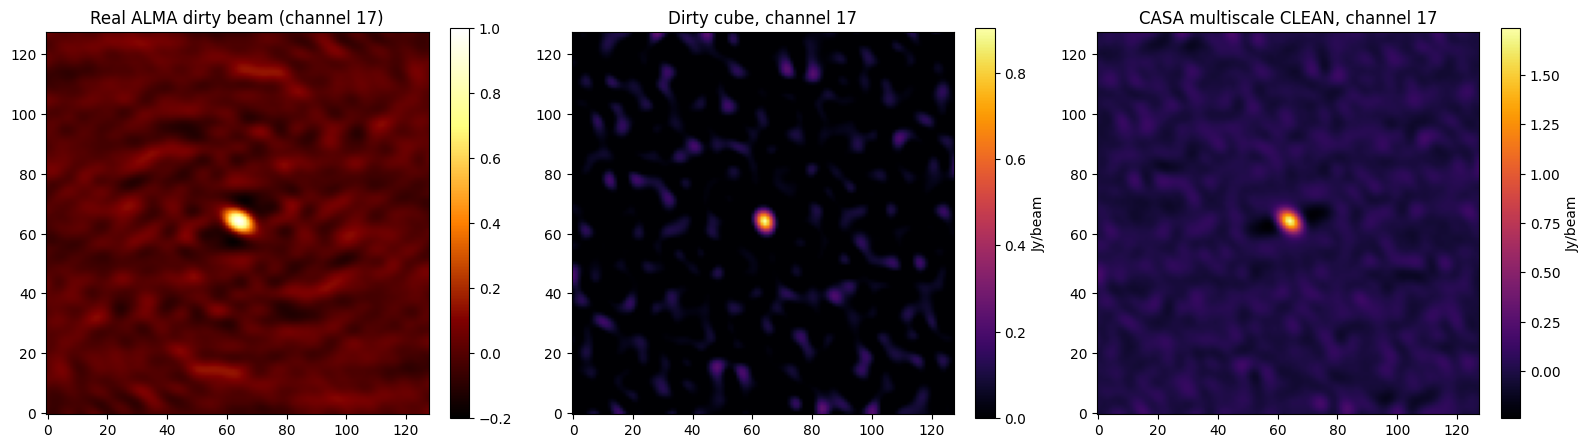

In [24]:
fig, axs = plt.subplots(1, 3, figsize=(16, 4.8))
im0 = axs[0].imshow(psf[peak_chan], origin='lower', cmap='afmhot', vmin=-0.2, vmax=1)
axs[0].set_title(f'Real ALMA dirty beam (channel {peak_chan})')
plt.colorbar(im0, ax=axs[0], fraction=0.046)
im1 = axs[1].imshow(dirty[peak_chan], origin='lower', cmap='inferno', vmin=0)
axs[1].set_title(f'Dirty cube, channel {peak_chan}')
plt.colorbar(im1, ax=axs[1], fraction=0.046, label='Jy/beam')
im2 = axs[2].imshow(benchmark[peak_chan], origin='lower', cmap='inferno')
axs[2].set_title(f'CASA multiscale CLEAN, channel {peak_chan}')
plt.colorbar(im2, ax=axs[2], fraction=0.046, label='Jy/beam')
plt.tight_layout()
plt.show()

In [6]:
print(benchmark.sum())

1991.2226566844356


## 5. 2D-1D wavelet deconvolution: soft, then reweighted soft

Both use `coarse_mode='keep'` (the coarse scale is not thresholded -- only
the dirty beam's genuinely-unmeasurable zero-spacing/short-spacing modes are
projected out each iteration, recovering the diffuse flux that plain
coarse-band zeroing discards). The reweighted run additionally corrects
soft-thresholding's amplitude bias via iteratively-reweighted L1 (see
`deconvolve_reweighted`), passing the true `sigma_noise` so its round-1 noise
calibration uses Monte-Carlo propagation rather than MAD-on-dirty (which
over-estimates sigma on an extended field like this one).

This runs inline (~3 min on the cropped cube).

In [7]:
dec = Deconvolver2D1D(num_scales_2d=4, num_scales_1d=3,
                      threshold_type='soft', positivity=True, verbose=True)

model_soft, history_soft = dec.deconvolve(
    dirty, psf_wavelet, sigma_noise,
    n_iter=100, k_start=6.0, k_end=2.5, fista=True, coarse_mode='keep',
)

[Deconvolver2D1D] 4 spatial scales x 3 spectral scales, 100 FISTA iterations (soft thresholding, coarse_mode='keep', reweight=False)
[Deconvolver2D1D] Lipschitz constant L=1654, step size mu=0.0006048
[Deconvolver2D1D] per-subband noise levels estimated (finest subband sigma=9.46e-06)
  [FISTA] iter    1/100  residual_std=0.04588  flux=101.6
  [FISTA] iter   11/100  residual_std=0.03609  flux=318.5
  [FISTA] iter   21/100  residual_std=0.03501  flux=336.7
  [FISTA] iter   31/100  residual_std=0.03449  flux=346.2
  [FISTA] iter   41/100  residual_std=0.03423  flux=351.9
  [FISTA] iter   51/100  residual_std=0.03398  flux=357.8
  [FISTA] iter   61/100  residual_std=0.03376  flux=363.4
  [FISTA] iter   71/100  residual_std=0.03356  flux=368.8
  [FISTA] iter   81/100  residual_std=0.03334  flux=374.6
  [FISTA] iter   91/100  residual_std=0.03314  flux=379.8
  [FISTA] iter  100/100  residual_std=0.03293  flux=385.3


In [15]:
model_rw, history_rw = dec.deconvolve(
    dirty, psf_wavelet, sigma_noise=sigma_noise,
    n_iter=300, burn_in_iters=50,
    k_start=5.0, lam=5, fista=True, coarse_mode='keep',
    reweight=True,
)

[Deconvolver2D1D] 4 spatial scales x 3 spectral scales, 300 FISTA iterations (soft thresholding, coarse_mode='keep', reweight=True)
[Deconvolver2D1D] Lipschitz constant L=1654, step size mu=0.0006048
[Deconvolver2D1D] reweight=True: burn_in=50 iterations (plain decaying threshold k_start=5.0->lam=5), then continuous per-iteration reweighting for the remaining 250 iterations. noise: Monte Carlo (fixed for the whole run)
  [FISTA+reweight] iter    1/300  residual_std=0.04572  flux=107.2
  [FISTA+reweight] iter   31/300  residual_std=0.03447  flux=346.3
  [FISTA+reweight] iter   61/300  residual_std=0.03249  flux=423.7
  [FISTA+reweight] iter   91/300  residual_std=0.0322  flux=423.7
  [FISTA+reweight] iter  121/300  residual_std=0.03207  flux=425.8
  [FISTA+reweight] iter  151/300  residual_std=0.03204  flux=425.3
  [FISTA+reweight] iter  181/300  residual_std=0.03203  flux=426.3
  [FISTA+reweight] iter  211/300  residual_std=0.03201  flux=427.3
  [FISTA+reweight] iter  241/300  residual

In [16]:
# restore both wavelet models with the CASA clean beam -> Jy/beam, same
# resolution and units as the CASA benchmark.
restored_soft = convolve_cube(model_soft, clean_beam)
restored_rw = convolve_cube(model_rw, clean_beam)

## 6. Comparison: CASA benchmark vs. dirty vs. our wavelet (soft, reweighted)

No ground truth, so this reports: peak brightness (Jy/beam), integrated flux
(Jy, = Jy/beam sum / beam area), off-source background noise std (the
denoising metric -- CLEAN-family images carry an unfiltered noise floor,
the wavelet fit thresholds it out), and RMSE of each wavelet reconstruction
against the CASA benchmark (how close we land to the professional result).

In [17]:
def rmse(a, b):
    return float(np.sqrt(np.mean((a - b) ** 2)))

# off-source background = outside the central 60x60 region
bg = np.ones((ny, nx), dtype=bool)
bg[34:94, 34:94] = False

rows = [
    ('Dirty (no deconvolution)', dirty, None),
    ('CASA multiscale CLEAN (benchmark)', benchmark, None),
    ('2D-1D wavelet, soft (restored)', restored_soft, model_soft),
    ('2D-1D wavelet, soft + reweighted (restored)', restored_rw, model_rw),
]
print(f"{'method':44s} {'peak':>10s} {'flux(Jy)':>10s} {'bg noise':>10s} {'RMSE vs CASA':>13s}")
for name, img, model in rows:
    peak = img.max()
    flux_jy = img.sum() / beam_area_px
    bg_std = img[:, bg].std()
    e = rmse(img, benchmark) if 'CASA' not in name else 0.0
    e_str = f'{e:13.4g}' if e else f'{"(ref)":>13s}'
    print(f'{name:44s} {peak:10.4f} {flux_jy:10.3f} {bg_std:10.4g} {e_str}')

method                                             peak   flux(Jy)   bg noise  RMSE vs CASA
Dirty (no deconvolution)                         0.9040      2.761    0.04647       0.03825
CASA multiscale CLEAN (benchmark)                1.7352     42.243     0.0397         (ref)
2D-1D wavelet, soft (restored)                   0.7087    364.720     0.0233        0.0504
2D-1D wavelet, soft + reweighted (restored)      0.7141    402.756    0.02528       0.05147


## 7. Channel maps: CASA benchmark vs. dirty vs. wavelet (soft vs. reweighted)

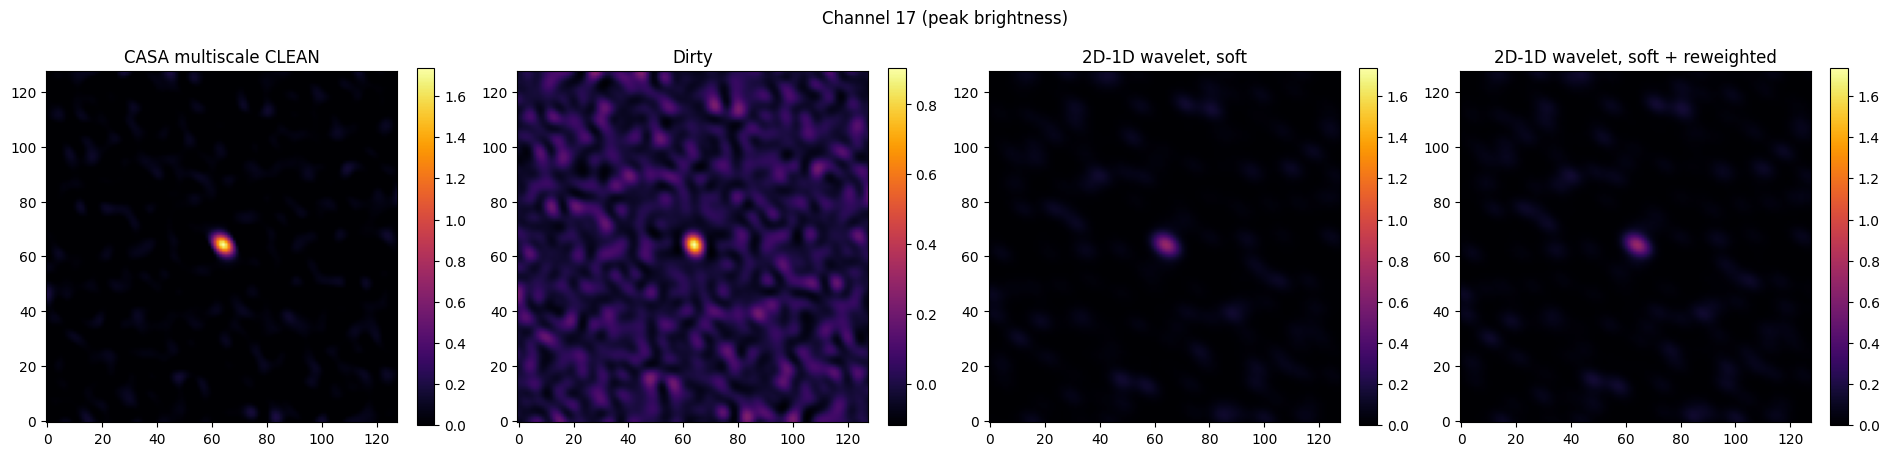

In [18]:
def compare_panels(k, title):
    fig, axs = plt.subplots(1, 4, figsize=(19, 4.6))
    vmax = max(benchmark[k].max(), restored_rw[k].max(), 1e-6)
    panels = [
        ('CASA multiscale CLEAN', benchmark[k], 0),
        ('Dirty', dirty[k], None),
        ('2D-1D wavelet, soft', restored_soft[k], 0),
        ('2D-1D wavelet, soft + reweighted', restored_rw[k], 0),
    ]
    for ax, (name, img, vmin) in zip(axs, panels):
        im = ax.imshow(img, origin='lower', cmap='inferno',
                        vmin=vmin, vmax=vmax if vmin is not None else None)
        ax.set_title(name)
        plt.colorbar(im, ax=ax, fraction=0.046)
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

compare_panels(peak_chan, f'Channel {peak_chan} (peak brightness)')

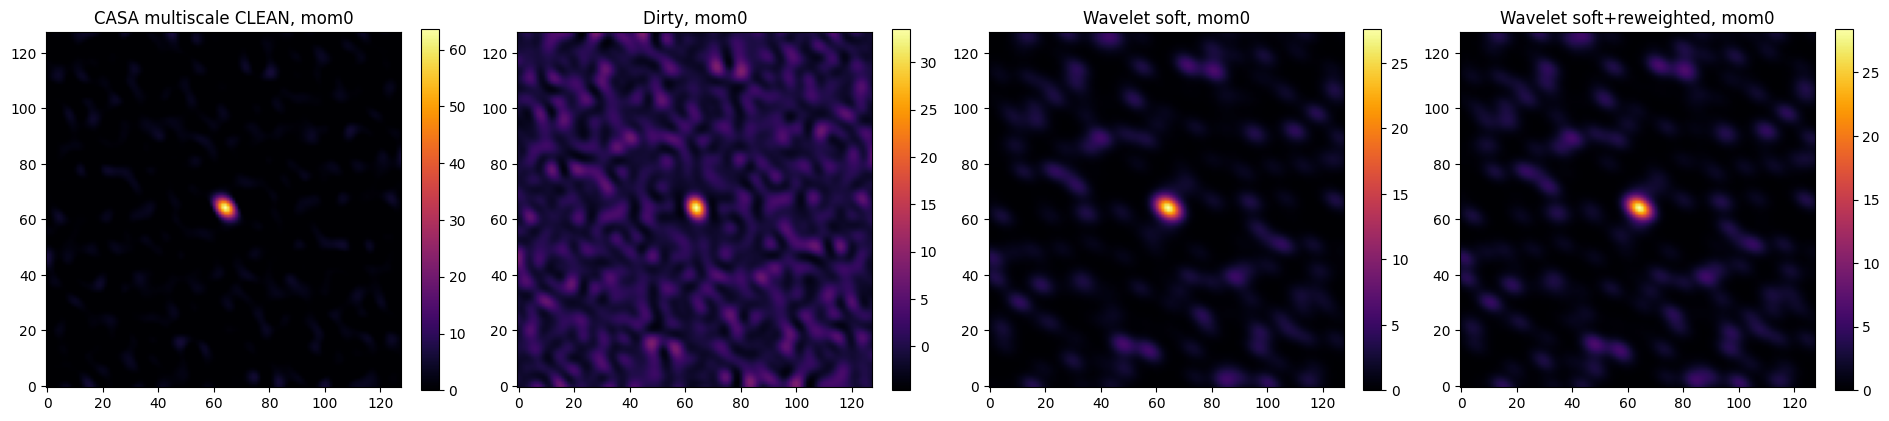

In [19]:
# moment-0 (channel-summed) comparison
fig, axs = plt.subplots(1, 4, figsize=(19, 4.6))
mom0 = [
    ('CASA multiscale CLEAN, mom0', benchmark.sum(0), 0),
    ('Dirty, mom0', dirty.sum(0), None),
    ('Wavelet soft, mom0', restored_soft.sum(0), 0),
    ('Wavelet soft+reweighted, mom0', restored_rw.sum(0), 0),
]
for ax, (name, img, vmin) in zip(axs, mom0):
    im = ax.imshow(img, origin='lower', cmap='inferno', vmin=vmin)
    ax.set_title(name)
    plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.show()

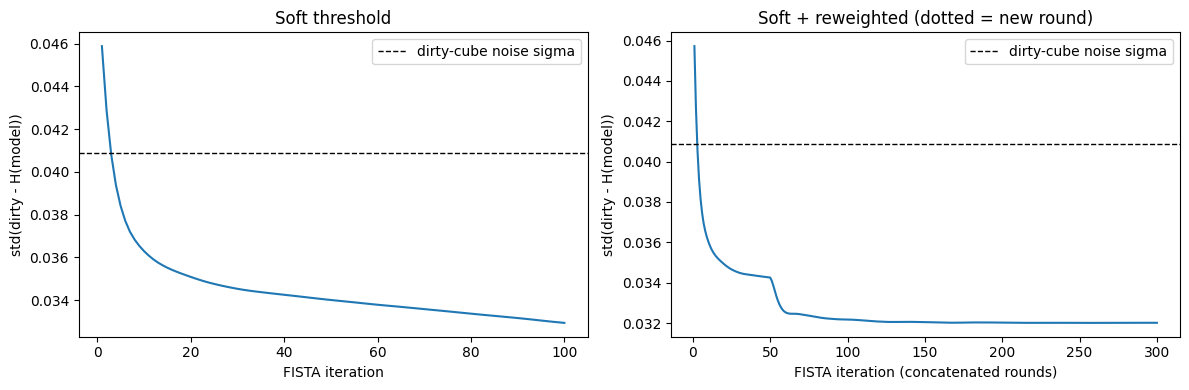

In [21]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))
axs[0].plot(np.arange(1, len(history_soft['residual_std']) + 1), history_soft['residual_std'])
axs[0].axhline(sigma_noise, color='k', linestyle='--', linewidth=1, label='dirty-cube noise sigma')
axs[0].set_xlabel('FISTA iteration'); axs[0].set_ylabel('std(dirty - H(model))')
axs[0].set_title('Soft threshold'); axs[0].legend()

axs[1].plot(np.arange(1, len(history_rw['residual_std']) + 1), history_rw['residual_std'])
axs[1].axhline(sigma_noise, color='k', linestyle='--', linewidth=1, label='dirty-cube noise sigma')
axs[1].set_xlabel('FISTA iteration (concatenated rounds)'); axs[1].set_ylabel('std(dirty - H(model))')
axs[1].set_title('Soft + reweighted (dotted = new round)'); axs[1].legend()
plt.tight_layout()
plt.show()

## Takeaways

- This is the hardest regime in the repo: a real ALMA dirty cube, a real
  (imperfectly-conditioned, channel-varying) per-channel dirty beam, real
  non-Gaussian noise/calibration artifacts, and **no ground truth** -- only
  CASA's own multiscale-CLEAN benchmark to compare against.
- Convolving our wavelet model with **CASA's own clean beam** (from the
  benchmark's `BEAMS` table) is what makes the comparison fair: both images
  then live at the same resolution and in the same Jy/beam units, so peak
  brightness and morphology line up rather than being offset by an
  unaccounted beam/units difference.
- The wavelet fit's **background noise suppression** is its clearest win:
  the off-source std is far below the dirty map's or CASA's, because the
  thresholding denoises as an intrinsic part of the fit, whereas CLEAN-family
  images add their unfiltered residual back. See the background-std column.
- **Reweighting + `coarse_mode='keep'`** recovers noticeably more flux and
  peak brightness than plain soft thresholding, for the reasons developed on
  the SONGS notebook: soft-threshold shrinkage bias is undone by the
  reweighting, and keeping (rather than zeroing) the coarse scale -- while
  projecting out only the beam's true zero-spacing null -- recovers diffuse
  flux that would otherwise be discarded. The residual short-spacing flux
  that neither method (nor CASA) can recover is a property of the uv
  coverage, not the algorithm.